# 08. Head-to-Head: SimpleRNN vs LSTM vs GRU vs BiLSTM — Keras (RNN/LSTM)

Everything so far, side by side. Same data, same training budget — only the recurrent layer changes. We build a comparison table and overlaid curves for **both** datasets.

**Two datasets, one concept:**
- **A) IMDB** movie reviews — many-to-one *text classification* (metric: accuracy).
- **B) Jena Climate** weather — sliding-window *temperature forecasting* (metric: MAE).

> Data prep lives in `rnn_data.py`; run `01_sequence_data_prep` once to build the caches.

---

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import rnn_data as R                      # shared loaders (see rnn_data.py)
keras.utils.set_random_seed(42)
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


In [2]:
def plot_history(h, metric, title=""):
    """Train (solid) vs validation (dashed): loss on the left, `metric` on the right."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history["loss"], label="train")
    ax[0].plot(h.history["val_loss"], "--", label="val")
    ax[0].set_title(title + " — loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h.history[metric], label="train")
    ax[1].plot(h.history["val_" + metric], "--", label="val")
    ax[1].set_title(title + " — " + metric); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## Part A — IMDB (accuracy, higher is better)

In [3]:
Xtr, ytr, Xte, yte = R.load_imdb(); cfg = R.imdb_config()

def imdb_variant(layer):
    keras.utils.set_random_seed(42)
    m = keras.Sequential([keras.Input((cfg["maxlen"],)),
                          layers.Embedding(cfg["num_words"], 32), layer,
                          layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]); return m

imdb_models = {
    "SimpleRNN": layers.SimpleRNN(32),
    "LSTM":      layers.LSTM(32),
    "GRU":       layers.GRU(32),
    "BiLSTM":    layers.Bidirectional(layers.LSTM(32)),
}
imdb_hist = {}
for name, layer in imdb_models.items():
    imdb_hist[name] = imdb_variant(layer).fit(Xtr, ytr, validation_data=(Xte, yte),
                                               epochs=4, batch_size=64, verbose=0)
    print("%-10s best test acc = %.3f" % (name, max(imdb_hist[name].history["val_accuracy"])))

SimpleRNN  best test acc = 0.800


LSTM       best test acc = 0.834


GRU        best test acc = 0.822


BiLSTM     best test acc = 0.823


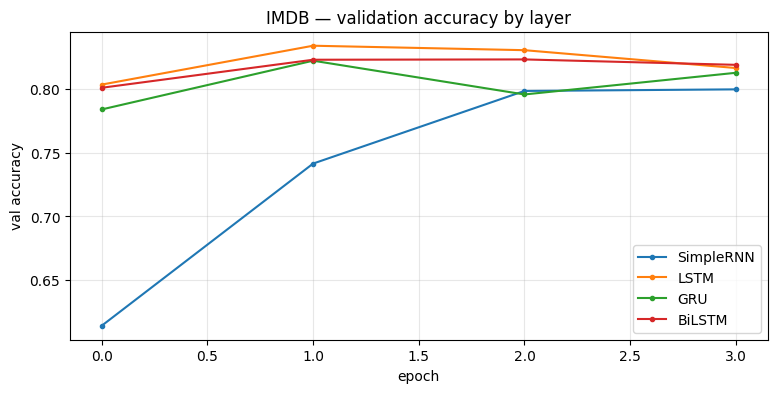

,best_test_acc,final_val_loss
LSTM,0.8340,0.4385
BiLSTM,0.8232,0.5216
GRU,0.8223,0.5079
SimpleRNN,0.7997,0.5253


In [4]:
import pandas as pd
imdb_tbl = pd.DataFrame({n: {"best_test_acc": max(h.history["val_accuracy"]),
                             "final_val_loss": h.history["val_loss"][-1]}
                         for n, h in imdb_hist.items()}).T.sort_values("best_test_acc", ascending=False)
plt.figure(figsize=(9, 4))
for n, h in imdb_hist.items():
    plt.plot(h.history["val_accuracy"], marker=".", label=n)
plt.title("IMDB — validation accuracy by layer"); plt.xlabel("epoch"); plt.ylabel("val accuracy")
plt.legend(); plt.grid(alpha=.3); plt.show()
imdb_tbl.round(4)

## Part B — Jena (MAE in degC, lower is better)

In [5]:
train_ds, val_ds, nfeat = R.make_jena_datasets(lookback=48, horizon=1, batch_size=128)
s = R.load_jena_series()

def jena_variant(layer):
    keras.utils.set_random_seed(42)
    m = keras.Sequential([keras.Input((None, nfeat)), layer, layers.Dense(1)])
    m.compile(optimizer="adam", loss="mse", metrics=["mae"]); return m

jena_models = {
    "SimpleRNN": layers.SimpleRNN(32),
    "LSTM":      layers.LSTM(32),
    "GRU":       layers.GRU(32),
    "BiLSTM":    layers.Bidirectional(layers.LSTM(32)),
}
jena_hist = {}
for name, layer in jena_models.items():
    jena_hist[name] = jena_variant(layer).fit(train_ds, validation_data=val_ds, epochs=6, verbose=0)
    print("%-10s best val MAE = %.3f  (~ %.2f degC)"
          % (name, min(jena_hist[name].history["val_mae"]),
             min(jena_hist[name].history["val_mae"]) * s["temp_std"]))

SimpleRNN  best val MAE = 0.137  (~ 1.19 degC)


LSTM       best val MAE = 0.138  (~ 1.20 degC)


GRU        best val MAE = 0.166  (~ 1.43 degC)


BiLSTM     best val MAE = 0.230  (~ 2.00 degC)


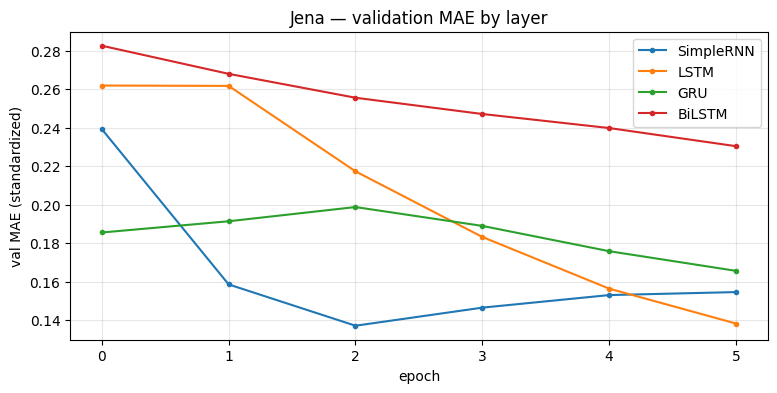

,best_val_mae,best_val_mae_degC
SimpleRNN,0.1370,1.1864
LSTM,0.1381,1.1963
GRU,0.1655,1.4338
BiLSTM,0.2304,1.9957


In [6]:
jena_tbl = pd.DataFrame({n: {"best_val_mae": min(h.history["val_mae"]),
                             "best_val_mae_degC": min(h.history["val_mae"]) * s["temp_std"]}
                         for n, h in jena_hist.items()}).T.sort_values("best_val_mae")
plt.figure(figsize=(9, 4))
for n, h in jena_hist.items():
    plt.plot(h.history["val_mae"], marker=".", label=n)
plt.title("Jena — validation MAE by layer"); plt.xlabel("epoch"); plt.ylabel("val MAE (standardized)")
plt.legend(); plt.grid(alpha=.3); plt.show()
jena_tbl.round(4)

## Takeaways
- **IMDB:** the gated layers (LSTM/GRU) and especially **BiLSTM** usually top SimpleRNN — long text rewards long memory and two-directional context.
- **Jena:** differences are smaller; a plain LSTM/GRU is typically enough because the forecast leans on recent hours. Sometimes SimpleRNN is competitive here.
- The lesson isn't "LSTM always wins" — it's **match the layer to the sequence structure**, and always compare under an equal budget.
- **Next:** `09_save_load`.